# Background detection exploration

Goal is to determine if we can find parts of the image outside of the lane markers which can be used for fault detection.

Testing: 
- Horizon
- Foliage 
- Outer marking

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch

In [2]:
# Import images
im_fn = "/home/daniel-choate/Datasets/VTTI_airfield/MSNV_0000_0000_0_250804_1830_00156/6_fps/Images_TSR/frame_"
ims_len = 10 
ims_start = 26809
im_int = 10
images = {}
for i in range(ims_len):
    im = im_fn + str(ims_start + i*im_int) + '.jpg'
    images[i] = cv2.imread(im)

# print(images[0])

### Segment out the runway 
Looking to focus on area outside the runway

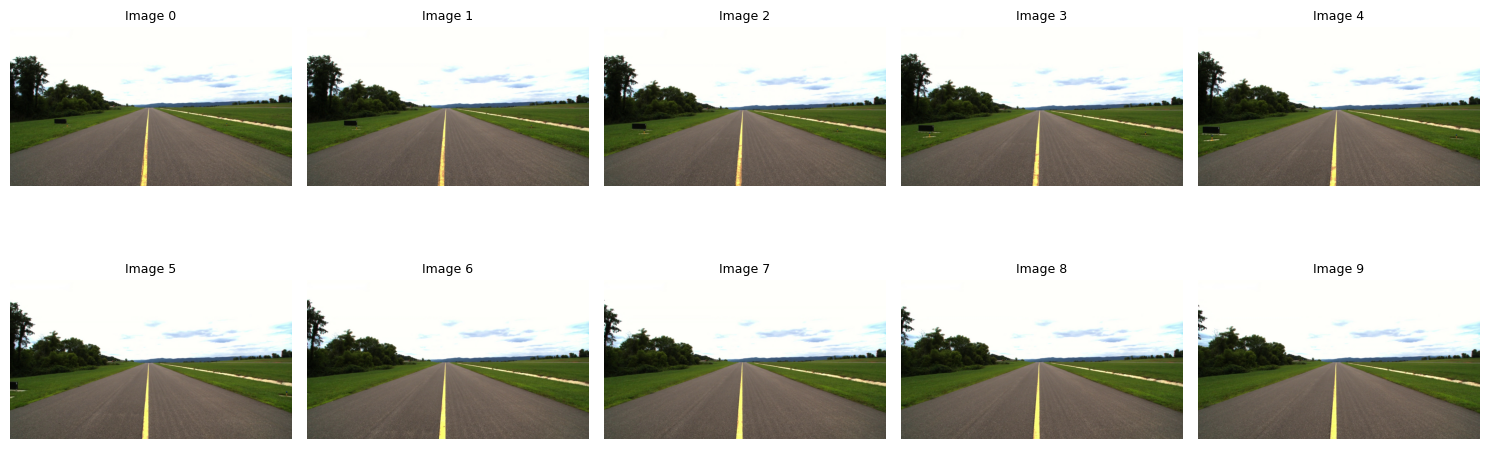

In [3]:
# List examples of a few images

ncols = 5
rows = int(np.ceil(len(images) / ncols))
fig, axs = plt.subplots(rows, ncols, figsize=(15, 3*rows), squeeze=False)

for ax in axs.flatten():
    ax.axis('off')

for imnum, ax in enumerate(axs.flatten()[:len(images)]):
    im = cv2.cvtColor(images[imnum], cv2.COLOR_BGR2RGB)
    ax.imshow(im)
    ax.set_title(f'Image {imnum}', fontsize=9)

plt.tight_layout()
plt.show()

In [4]:
# Load SAM2 image predictor
from sam2.sam2_image_predictor import SAM2ImagePredictor

device = "cuda" if torch.cuda.is_available() else "cpu"
predictor = SAM2ImagePredictor.from_pretrained("facebook/sam2.1-hiera-large", device=device)

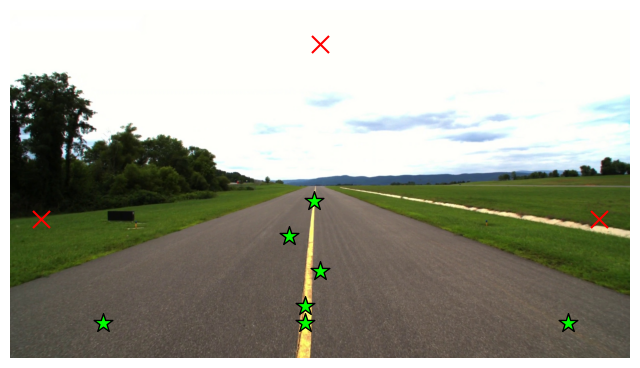

In [5]:
# Point prompts as fractions of (width, height) - adjust after checking the plot below
# label 1 = runway, 0 = not runway
pos_pts = [(0.475, 0.90), (0.50, 0.75), (0.45, 0.65), (0.49, 0.55), (0.9, 0.9), (0.15, 0.9), (0.475, 0.85)]
neg_pts = [(0.50, 0.10), (0.05, 0.60), (0.95, 0.60)]

def get_prompts(im):
    h, w = im.shape[:2]
    pts = np.array([(x*w, y*h) for x, y in pos_pts + neg_pts], dtype=np.float32)
    labels = np.array([1]*len(pos_pts) + [0]*len(neg_pts), dtype=np.int32)
    return pts, labels

# Show prompts on first image
im = cv2.cvtColor(images[0], cv2.COLOR_BGR2RGB)
pts, labels = get_prompts(im)
plt.figure(figsize=(8, 5))
plt.imshow(im)
plt.scatter(pts[labels == 1, 0], pts[labels == 1, 1], c='lime', marker='*', s=200, edgecolor='k')
plt.scatter(pts[labels == 0, 0], pts[labels == 0, 1], c='red', marker='x', s=150)
plt.axis('off')
plt.show()

In [6]:
# Segment runway in each image 
runway_masks = {}
with torch.inference_mode(), torch.autocast(device, dtype=torch.bfloat16):
    for i in range(len(images)):
        im = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
        predictor.set_image(im)
        pts, labels = get_prompts(im) # Get prompts from each image 
        masks, scores, _ = predictor.predict(point_coords=pts, point_labels = labels, multimask_output=False)
        runway_masks[i] = masks[0].astype(bool)
        print(f'Image {i}: score {scores[0]:.3f}') 

Image 0: score 0.984
Image 1: score 0.984
Image 2: score 0.988
Image 3: score 0.988
Image 4: score 0.988
Image 5: score 0.988
Image 6: score 0.988
Image 7: score 0.988
Image 8: score 0.988
Image 9: score 0.984


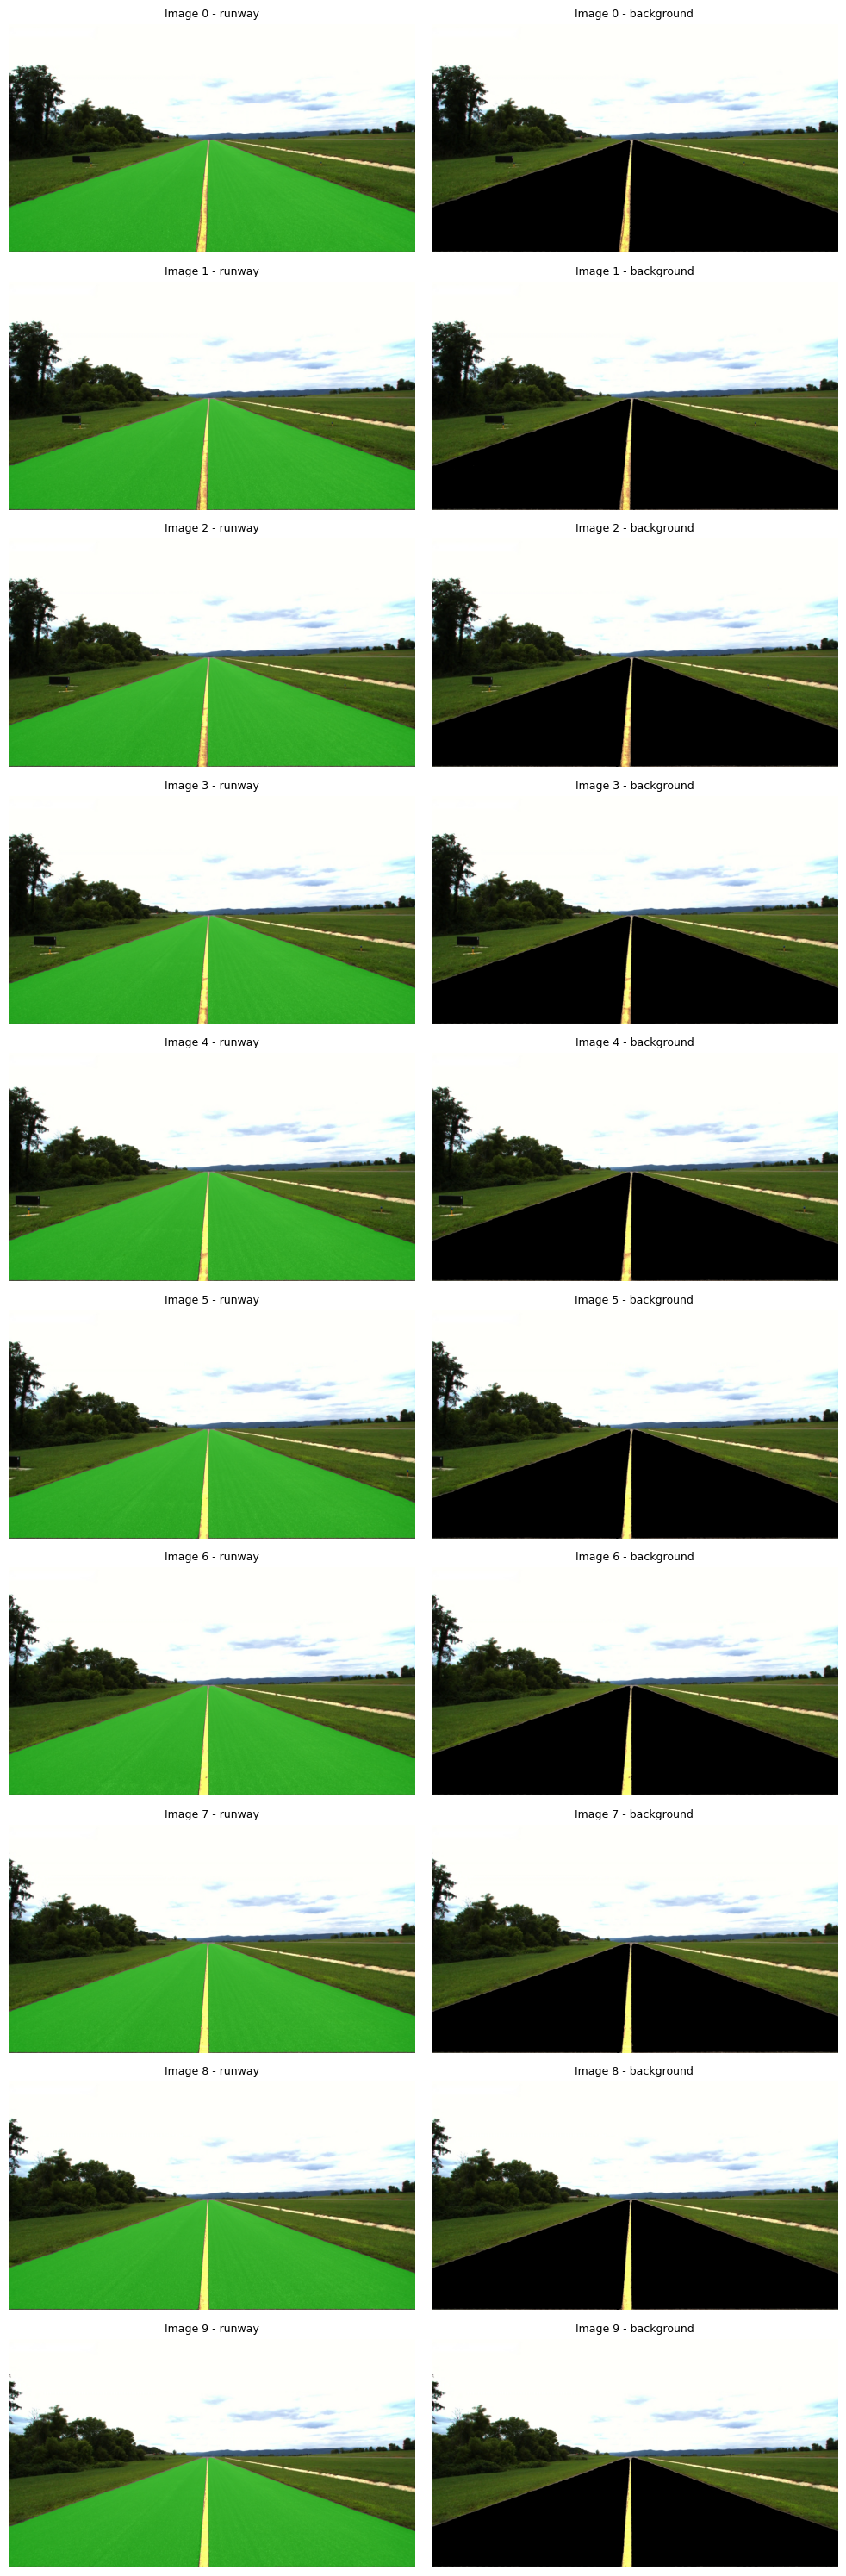

In [7]:
# Show runway (green) and background outside runway 
fig, axs = plt.subplots(len(images), 2, figsize=(10, 3*len(images)), squeeze=False)
for i in range(len(images)):
    im = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
    overlay = im.copy()
    overlay[runway_masks[i]] = (0.5*overlay[runway_masks[i]] + 0.5*np.array([0,255,0])).astype(np.uint8)
    background = im * ~runway_masks[i][..., None] # ~ is NOT for boolean arrays 
    axs[i, 0].imshow(overlay)
    axs[i, 0].set_title(f"Image {i} - runway", fontsize=9)
    axs[i, 1].imshow(background)
    axs[i, 1].set_title(f"Image {i} - background", fontsize=9)

for ax in axs.flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()

In [8]:
# Fill centerline and other missed markings 

def fill_runway(mask, min_frac=0.02):
    m = mask.astype(np.uint8)
    # Generate blobs gathered by the mask: lab is image with labels of which blob it belongs to
    n, lab, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    # Keeps blob if covering more than min_frac of the image
    keep = [k for k in range(1, n) if stats[k, cv2.CC_STAT_AREA] > min_frac * m.size] 
    m = np.isin(lab, keep).astype(np.uint8)
    # Convex hull of all kept pixels
    pts = cv2.findNonZero(m)
    hull = cv2.convexHull(pts)
    filled = np.zeros_like(m)
    cv2.fillConvexPoly(filled, hull, 1)
    return filled.astype(bool)

runway_filled = {i: fill_runway(runway_masks[i]) for i in runway_masks}

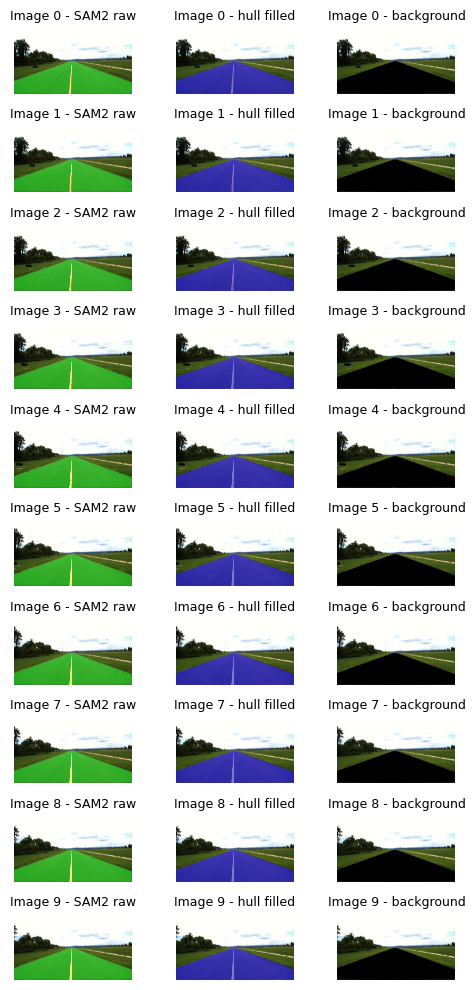

In [9]:
# Compare raw SAM2 mask vs hull-filled
fig, axs = plt.subplots(len(images), 3, figsize=(5, 1*len(images)), squeeze=False)
for i in range(len(images)):
    im = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
    raw = im.copy()
    raw[runway_masks[i]] = (0.5*raw[runway_masks[i]] + 0.5*np.array([0, 255, 0])).astype(np.uint8)
    filled = im.copy()
    filled[runway_filled[i]] = (0.5*filled[runway_filled[i]] + 0.5*np.array([0, 0, 255])).astype(np.uint8)
    background = im * ~runway_filled[i][..., None]
    axs[i, 0].imshow(raw)
    axs[i, 0].set_title(f'Image {i} - SAM2 raw', fontsize=9)
    axs[i, 1].imshow(filled)
    axs[i, 1].set_title(f'Image {i} - hull filled', fontsize=9)
    axs[i, 2].imshow(background)
    axs[i, 2].set_title(f'Image {i} - background', fontsize=9)
for ax in axs.flatten():
    ax.axis('off')
plt.tight_layout()
plt.show()

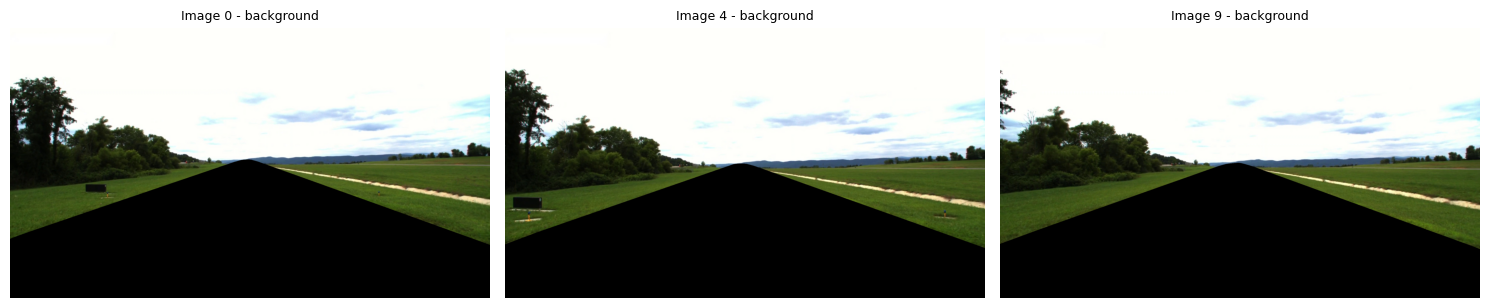

In [10]:
# Background mask: widen the filled runway so features on the runway edge are excluded
edge_margin = 30 # px
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*edge_margin + 1, 2*edge_margin + 1))
background_masks = {i: ~cv2.dilate(runway_filled[i].astype(np.uint8), kernel).astype(bool) for i in runway_filled}

# Check on a few frames
fig, axs = plt.subplots(1, 3, figsize=(15, 3))
for ax, i in zip(axs, [0, 4, 9]):
    im = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
    ax.imshow(im * background_masks[i][..., None])
    ax.set_title(f'Image {i} - background', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

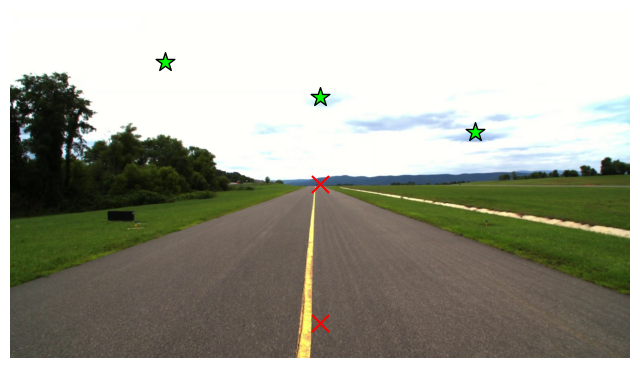

In [11]:
# Sky prompts as fractions of (width, height) - adjust after checking the plot below
# label 1 = sky, 0 = not sky
sky_pos_pts = [(0.25, 0.15), (0.50, 0.25), (0.75, 0.35)]
sky_neg_pts = [(0.50, 0.90), (0.5, 0.5)]

def get_sky_prompts(im):
    h, w = im.shape[:2]
    pts = np.array([(x*w, y*h) for x, y in sky_pos_pts + sky_neg_pts], dtype=np.float32)
    labels = np.array([1]*len(sky_pos_pts) + [0]*len(sky_neg_pts), dtype=np.int32)
    return pts, labels

# Show prompts on first image
im = cv2.cvtColor(images[0], cv2.COLOR_BGR2RGB)
pts, labels = get_sky_prompts(im)
plt.figure(figsize=(8, 5))
plt.imshow(im)
plt.scatter(pts[labels == 1, 0], pts[labels == 1, 1], c='lime', marker='*', s=200, edgecolor='k')
plt.scatter(pts[labels == 0, 0], pts[labels == 0, 1], c='red', marker='x', s=150)
plt.axis('off')
plt.show()

Image 0: score 0.988, sky covers 40% of image
Image 1: score 0.988, sky covers 41% of image
Image 2: score 0.988, sky covers 42% of image
Image 3: score 0.988, sky covers 42% of image
Image 4: score 0.988, sky covers 42% of image
Image 5: score 0.988, sky covers 42% of image
Image 6: score 0.988, sky covers 42% of image
Image 7: score 0.988, sky covers 42% of image
Image 8: score 0.988, sky covers 42% of image
Image 9: score 0.988, sky covers 43% of image


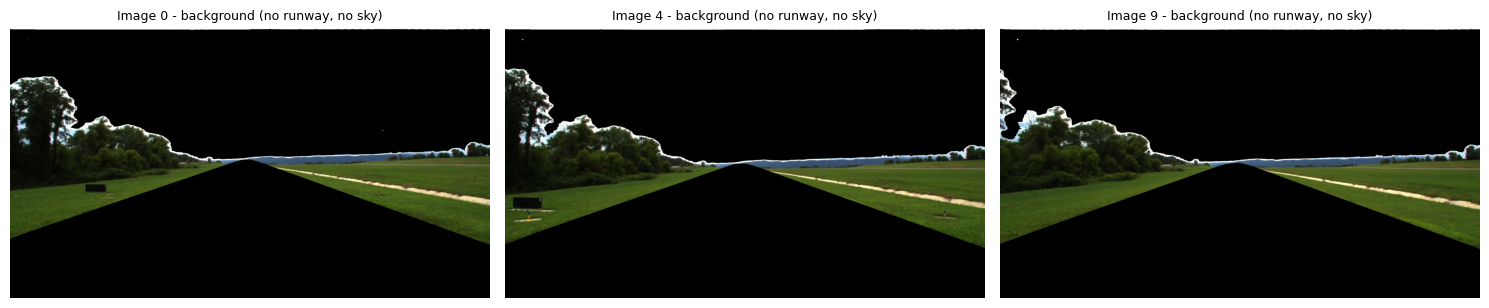

In [12]:
# Segment sky in each image and remove it from the background
sky_masks = {}
with torch.inference_mode(), torch.autocast(device, dtype=torch.bfloat16):
    for i in range(len(images)):
        im = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
        predictor.set_image(im)
        pts, labels = get_sky_prompts(im)
        masks, scores, _ = predictor.predict(point_coords=pts, point_labels=labels, multimask_output=False)
        sky_masks[i] = masks[0].astype(bool)
        background_masks[i] &= ~sky_masks[i]
        print(f'Image {i}: score {scores[0]:.3f}, sky covers {100*sky_masks[i].mean():.0f}% of image')

# Check on a few frames
fig, axs = plt.subplots(1, 3, figsize=(15, 3))
for ax, i in zip(axs, [0, 4, 9]):
    im = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
    ax.imshow(im * background_masks[i][..., None])
    ax.set_title(f'Image {i} - background (no runway, no sky)', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

Image 0: 4977 ORB keypoints


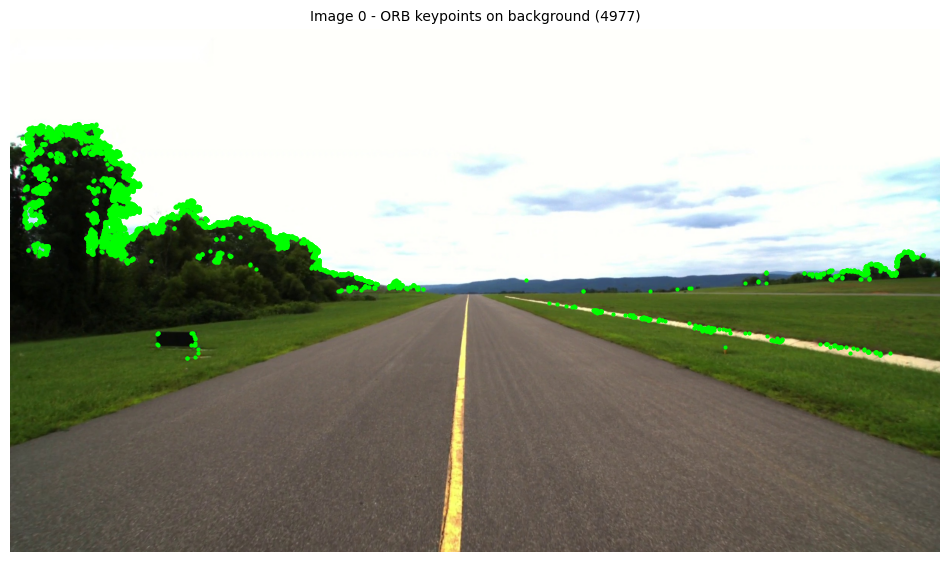

In [13]:
# Basic ORB feature descriptor
orb = cv2.ORB_create(nfeatures=5000)

i = 0
gray = cv2.cvtColor(images[i], cv2.COLOR_BGR2GRAY)
mask = background_masks[i].astype(np.uint8) * 255
kps, des = orb.detectAndCompute(gray, mask)
print(f'Image {i}: {len(kps)} ORB keypoints')

# Show keypoints on the image
pts = np.float32([kp.pt for kp in kps])
im = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 7))
plt.imshow(im)
plt.scatter(pts[:, 0], pts[:, 1], s=4, c='lime')
plt.title(f'Image {i} - ORB keypoints on background ({len(kps)})', fontsize=10)
plt.axis('off')
plt.show()

In [14]:
# ORB keypoints + descriptors on background of every frame
orb_kps, orb_des = {}, {}
for i in range(len(images)):
    gray = cv2.cvtColor(images[i], cv2.COLOR_BGR2GRAY)
    mask = background_masks[i].astype(np.uint8) * 255
    orb_kps[i], orb_des[i] = orb.detectAndCompute(gray, mask)

# Brute force Hamming matcher (ORB descriptors are binary) + Lowe's ratio test 
bf = cv2.BFMatcher(cv2.NORM_HAMMING)
ratio = 0.75

def match_frames(i, j):
    knn = bf.knnMatch(orb_des[i], orb_des[j], k=2)
    # Keep match if distance between best and second best 
    good = [m[0] for m in knn if len(m) == 2 and m[0].distance < ratio * m[1].distance]
    pts_i = np.float32([orb_kps[i][m.queryIdx].pt for m in good])
    pts_j = np.float32([orb_kps[j][m.trainIdx].pt for m in good])
    return good, pts_i, pts_j

i, j = 0,1
good, pts_i, pts_j = match_frames(i,j)
print(f'Image {i}: {len(orb_kps[i])} kps, Image {j}: {len(orb_kps[j])} kps, {len(good)} matches after ratio test')

Image 0: 4977 kps, Image 1: 4981 kps, 2143 matches after ratio test


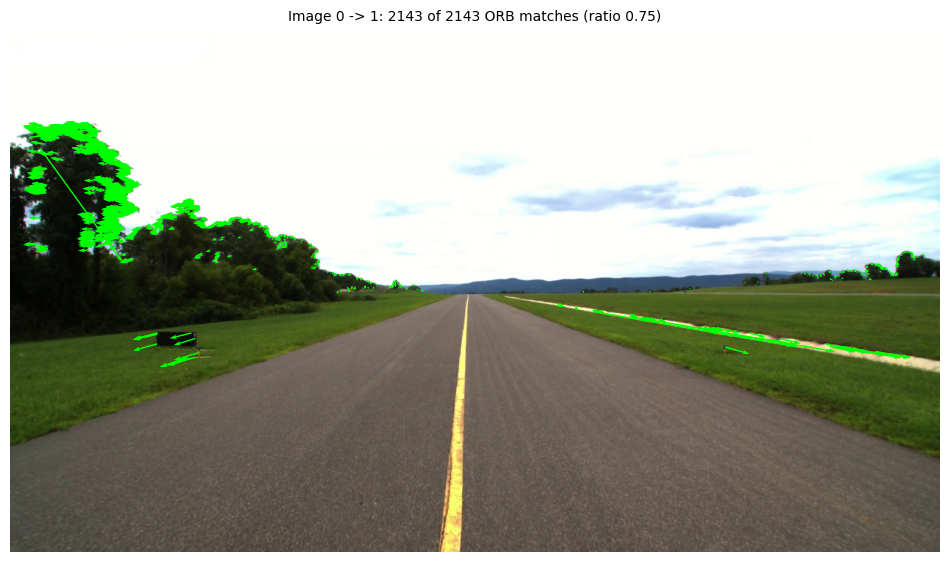

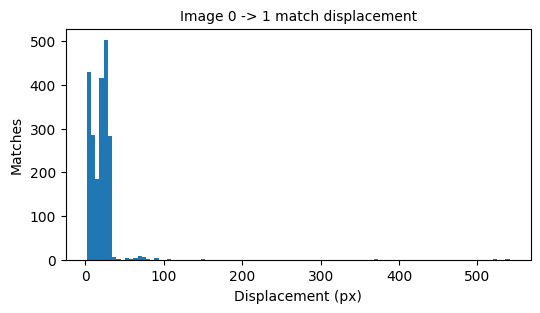

In [15]:
# Show matches as flow arrows on frame i (keypoint in i -> matched location in j)
flow = pts_j - pts_i
n_plot = 3000 # random subset so the arrows are readable
rng = np.random.default_rng(0)
idx = rng.choice(len(pts_i), size=min(n_plot, len(pts_i)), replace=False)
im = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12,7))
plt.imshow(im)
plt.quiver(pts_i[idx, 0], pts_i[idx, 1], flow[idx, 0], flow[idx, 1], color='lime', 
           angles = 'xy', scale_units='xy', scale=1, width = 0.0015)
plt.title(f'Image {i} -> {j}: {len(idx)} of {len(good)} ORB matches (ratio {ratio})', fontsize=10)
plt.axis('off')
plt.show()

# Match displacement magnitudes (all matches) - wild outliers show up as a long tail
plt.figure(figsize=(6, 3))
plt.hist(np.linalg.norm(flow, axis=1), bins=100)
plt.xlabel('Displacement (px)')
plt.ylabel('Matches')
plt.title(f'Image {i} -> {j} match displacement', fontsize=10)
plt.show()

In [16]:
# Filter matches
max_disp = 500 # maximum pixel travel distance
ransac_thresh = 1.0 # max distance from epipolar line to count as inlier

# DISTANCE calc - sampson threshold: used for inlier calculations 
def sampson_dist(F, p1, p2):
    # First order approximation of the distance of each match from its epipolar line
    x1 = np.hstack([p1, np.ones((len(p1), 1))])
    x2 = np.hstack([p2, np.ones((len(p2), 1))])
    Fx1 = x1 @ F.T # epipolar lines in frame j
    Ftx2 = x2 @ F # epipolar lines in frame i
    num = np.sum(x2 * Fx1, axis=1)**2 # (x'^T F x)^2
    den = Fx1[:, 0]**2 + Fx1[:, 1]**2 + Ftx2[:, 0]**2 + Ftx2[:, 1]**2
    return np.sqrt(num / den)


def filter_matches(pts_i, pts_j):
    # Displacement 
    gate = np.linalg.norm(pts_j - pts_i, axis=1) < max_disp
    # RANSAC
    F, ransac_mask = cv2.findFundamentalMat(pts_i[gate], pts_j[gate], cv2.FM_RANSAC, ransac_thresh, 0.999)
    # F, ransac_mask = cv2.findFundamentalMat(pts_i[gate], pts_j[gate], cv2.USAC_MAGSAC, 1.0, 0.999)
    inliers = np.zeros(len(pts_i), dtype=bool)
    inliers[np.flatnonzero(gate)[ransac_mask.ravel() == 1]] = True
    return F, gate, inliers

In [17]:
F, gate, inliers = filter_matches(pts_i, pts_j)
resid = sampson_dist(F, pts_i[inliers], pts_j[inliers])
print(f'Image {i} -> {j}: {len(pts_i)} matches, {gate.sum()} pass {max_disp}px gate, '
      f'{inliers.sum()} RANSAC inliers ({100*inliers.mean():.0f}%)')
print(f'Inlier Sampson residual: median {np.median(resid):.3f} px, max {resid.max():.3f} px')
print('F =\n', F)



Image 0 -> 1: 2143 matches, 2141 pass 500px gate, 1462 RANSAC inliers (68%)
Inlier Sampson residual: median 0.259 px, max 0.699 px
F =
 [[-9.47548826e-08 -8.34888309e-05  5.46641964e-02]
 [ 8.48067575e-05 -2.91386832e-07 -7.17382660e-02]
 [-5.57581151e-02  7.08048064e-02  1.00000000e+00]]


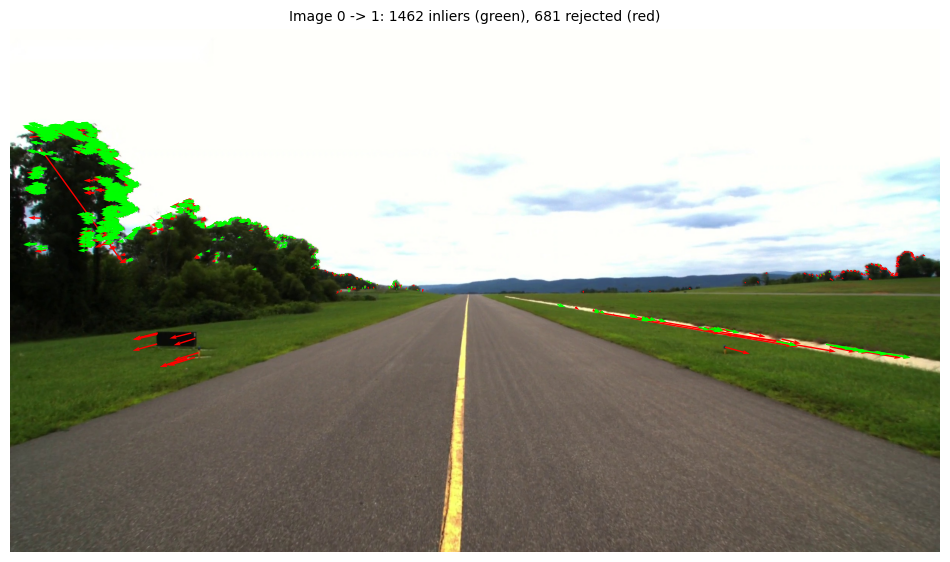

In [18]:
# Inliers (green) vs rejected (red) - random subset for readability
flow = pts_j - pts_i
rng = np.random.default_rng(0)
idx = rng.choice(len(pts_i), size=min(n_plot, len(pts_i)), replace=False)
in_idx, out_idx = idx[inliers[idx]], idx[~inliers[idx]]
im = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 7))
plt.imshow(im)
plt.quiver(pts_i[out_idx, 0], pts_i[out_idx, 1], flow[out_idx, 0], flow[out_idx, 1], color='red',
           angles='xy', scale_units='xy', scale=1, width=0.0015)
plt.quiver(pts_i[in_idx, 0], pts_i[in_idx, 1], flow[in_idx, 0], flow[in_idx, 1], color='lime',
           angles='xy', scale_units='xy', scale=1, width=0.0015)
plt.title(f'Image {i} -> {j}: {inliers.sum()} inliers (green), {(~inliers).sum()} rejected (red)', fontsize=10)
plt.axis('off')
plt.show()